# Importación de bibliotecas

In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

import flopy
from flopy.plot.styles import styles
import xmf6
from flow_1D import build_gwf_1D, plot_flow_1D
from tran_1D import build_gwt_1D, plot_tran_1D
# Funciones para cálculo de la solución analítica
from wexler1_test import sol_analytical_t
# Definición de parámetros de decaimiento y sorción
from sorption_decay import *

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import flopy
import os
import xmf6

In [3]:
def get_mst_dict(phys):
    mst = dict(
        porosity = phys["porosity"],
        sorption = None,
        bulk_density = None,
        distcoef = None, 
        first_order_decay = None,
        decay = None,
        decay_sorbed = None
    )
    
    if phys["retardation_factor"] > 1.0:
        mst["sorption"] = "linear"
        mst["bulk_density"] = 1.0
        mst["distcoef"] = (phys["retardation_factor"] - 1.0) * phys["porosity"] / mst["bulk_density"]

    if phys["decay_rate"] != 0.0:
        mst["first_order_decay"] = True
        mst["decay"] = phys["decay_rate"]
        if phys["retardation_factor"] > 1.0:
            mst["decay_sorbed"] = phys["decay_rate"]

    return mst

In [5]:
long_disp = [0.1, 1.0, 1.0, 1.0]
reta_fact = [1.0, 1.0, 2.0, 1.0]
deca_rate = [0.0, 0.0, 0.0, 0.01]
dir_names = ['p01a','p01b','p01c','p01d']

case = int(input("Caso (1-4)= ")) - 1 # 0, 1, 2, 3
dirname = dir_names[case]

phys = dict(
    specific_discharge = 0.1,  # Specific discharge ($cm s^{-1}$)
    hydraulic_conductivity = 0.01,  # Hydraulic conductivity ($cm s^{-1}$)
    source_concentration = 1.0,  # Source concentration (unitless)
    porosity = 0.1,  # Porosity of mobile domain (unitless)
    initial_concentration = 0.0,  # Initial concentration (unitless)
    longitudinal_dispersivity = long_disp[case],
    retardation_factor = reta_fact[case],
    decay_rate = deca_rate[case]
)
phys["dispersion_coefficient"] = phys["longitudinal_dispersivity"] * \
                                   phys["specific_discharge"] / phys["retardation_factor"]

xmf6.nice_print(phys, "Parámetros físicos")

Caso (1-4)=  1



Parámetros físicos
――――――――――――――――――
       specific_discharge = 0.1
   hydraulic_conductivity = 0.01
     source_concentration = 1.0
                 porosity = 0.1
    initial_concentration = 0.0
longitudinal_dispersivity = 0.1
       retardation_factor = 1.0
               decay_rate = 0.0
   dispersion_coefficient = 0.010000000000000002
――――――――――――――――――


# Parámetros del problema

In [6]:
# Parámetros de la simulación (flopy.mf6.MFSimulation)
init = {
    'sim_name' : "flow",
    'exe_name' : "C:\\Users\\luiggi\\Documents\\GitSites\\xmf6\\mf6\\windows\\mf6",
#    'exe_name' : "../../mf6/macosarm/mf6",
    'sim_ws' : "output_flow_trans_1D"
}

# Parámetros para el tiempo (flopy.mf6.ModflowTdis)
tdis = {
    'units': "seconds",
    'nper' : 1,
    'perioddata': [(120.0, 240, 1.0)]
}

# Parámetros para la solución numérica (flopy.mf6.ModflowIms)
ims = {}

# Parámetros para el modelo de flujo (flopy.mf6.ModflowGwf)
gwf = { 
    'modelname': init["sim_name"],
    'save_flows': True
}

# Parámetros para la discretización espacial (flopy.mf6.ModflowGwfdis)
dis = {
    'length_units' : "centimeters",
    'nlay': 1, 
    'nrow': 1, 
    'ncol': 120,
    'delr': 0.1, 
    'delc': 0.1, 
    'top' : 1.0, 
    'botm': 0.0 
}

# Parámetros para las condiciones iniciales (flopy.mf6.ModflowGwfic)
ic = {
    'strt': 1.0
}

# Parámetros para las condiciones de frontera (flopy.mf6.ModflowGwfchd)
chd = {
    'stress_period_data': [[(0, 0, dis['ncol'] - 1), 1.0]],     
}

# Parámetros para las propiedades de flujo (flopy.mf6.ModflowGwfnpf)
npf = {
    'save_specific_discharge': True,
    'save_saturation': True,
    'icelltype':  0,
    'k': phys["hydraulic_conductivity"] # Hydraulic conductivity ($cm s^{-1}$) 
}

# Parámetros para las propiedades de los pozos (flopy.mf6.ModflowGwfwel)
q = phys["specific_discharge"] * dis['delc'] * dis['delr'] * dis['top']
well = {
    'stress_period_data': [[(0, 0, 0), q, phys["source_concentration"],]],
    'pname': "WEL-1",
    'auxiliary' : ["CONCENTRATION"],
#    'save_flows': True
}

# Parámetros para almacenar y mostrar la salida de la simulación (flopy.mf6.ModflowGwfoc)
oc = {
    'budget_filerecord': f"{init['sim_name']}.bud",
    'head_filerecord': f"{init['sim_name']}.hds",
    'saverecord': [("HEAD", "ALL"), ("BUDGET", "ALL")],
#    'printrecord': [("HEAD", "ALL")]
}

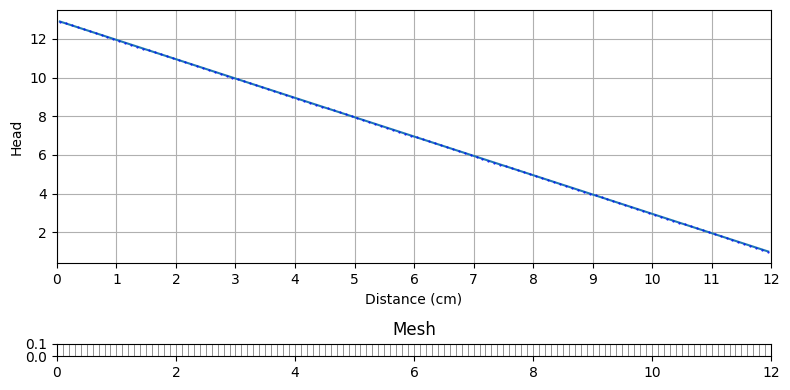

In [7]:
# --- Inicialización de la simulación ---
o_simf = xmf6.common.init_sim(silent = True, init = init, tdis = tdis, ims = ims)
o_gwf, packages = xmf6.gwf.set_packages(o_simf, silent = True,
                                        gwf = gwf, 
                                        dis = dis, ic = ic, chd = chd, npf = npf, oc = oc, well = well)
# --- Escritura de archivos ---
o_simf.write_simulation(silent = True)

# --- Ejecución de la simulación ---
o_simf.run_simulation(silent = True)

# --- Recuperamos los resultados de la simulación ---
head = xmf6.gwf.get_head(o_gwf)
qx, qy, qz, n_q = xmf6.gwf.get_specific_discharge(o_gwf, text="DATA-SPDIS")

x, y, z = o_gwf.modelgrid.xyzcellcenters
row_length = o_gwf.modelgrid.extent[1]

# --- Definición de la figura ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize =(8,4), height_ratios=[2,0.1])

# --- Gráfica 1. ---
#plt.rcParams['font.family'] = 'DeJavu Sans'
ax1.plot(x[0], head[0, 0], marker=".", ls ="-", mec="blue", mfc="none", markersize="1", label = 'Head')
ax1.set_xlim(0, 12)
ax1.set_xticks(ticks=np.linspace(0, row_length,13))
ax1.set_xlabel("Distance (cm)")
ax1.set_ylabel("Head")
ax1.grid()

# --- Gráfica 2. ---
pmv = flopy.plot.PlotMapView(o_gwf, ax=ax2)
pmv.plot_grid(colors='dimgray', lw=0.5)
ax2.set_yticks(ticks=[0, 0.1])#, fontsize=8)
ax2.set_title("Mesh")
plt.tight_layout()
plt.show()

In [8]:
# Parámetros de la simulación (flopy.mf6.MFSimulation)
init_t = {
    'sim_name' : "trans",
    'exe_name' : "C:\\Users\\luiggi\\Documents\\GitSites\\xmf6\\mf6\\windows\\mf6",
#    'exe_name' : "../../mf6/macosarm/mf6",
    'sim_ws' : "output_flow_trans_1D"
}

# Parámetros para el tiempo (flopy.mf6.ModflowTdis)
#El mismo tdis de flow

# Parámetros para la solución numérica (flopy.mf6.ModflowIms)
ims_t = {
    'linear_acceleration': "bicgstab"
}

# Parámetros para el modelo de transporte (flopy.mf6.ModflowGwt)
gwt = { 
    'modelname': init["sim_name"],
    'save_flows': True
}

# Parámetros para la discretización espacial (flopy.mf6.ModflowGwtdis)
# El mismo dis de flow

# Parámetros para las condiciones iniciales (flopy.mf6.ModflowGwtic)
ic_t = {
    'strt': 0.0
}

# Parámetros para MST (flopy.mf6.ModflowGwtmst)
mst = get_mst_dict(phys)

# Parámetros para ADV (flopy.mf6.ModflowGwtadv)
adv = {
    "scheme" : "TVD"
}

# Parámetros para DSP (flopy.mf6.ModflowGwtdsp)
dsp = {
    "xt3d_off" : True,
    "alh" : phys["longitudinal_dispersivity"],
    "ath1" : phys["longitudinal_dispersivity"],
}

# Parámetros para FMI (flopy.mf6.ModflowGwtfmi)
fmi = {
    "packagedata" : [("GWFHEAD", f"{init['sim_name']}.hds", None),
                     ("GWFBUDGET", f"{init['sim_name']}.bud", None),
                    ]
}

# Parámetros para SSM (flopy.mf6.ModflowGwtssm)
ssm = {
    "sources" : [["WEL-1", "AUX", "CONCENTRATION"]]
}

# Parámetros para OBS (flopy.mf6.ModflowGwtobs)
obs = {
    "digits" : 10, 
    "print_input" : True, 
    "continuous" : {
        "transporte.obs.csv": [
            ("X005", "CONCENTRATION", (0, 0, 0)),
            ("X405", "CONCENTRATION", (0, 0, 40)),
            ("X1105", "CONCENTRATION", (0, 0, 110)),
        ],
    }
}

# Parámetros para almacenar y mostrar la salida de la simulación (flopy.mf6.ModflowGwtoc)
oc_t = {
    'budget_filerecord': f"{init['sim_name']}.bud",
    'concentration_filerecord': f"{init['sim_name']}",
    'saverecord' : [("CONCENTRATION", "ALL"), ("BUDGET", "LAST")],
    'printrecord' : [("CONCENTRATION", "LAST"), ("BUDGET", "LAST")],
}


# --- Inicialización de la simulación ---
o_simt = xmf6.common.init_sim(silent = True, init = init_t, tdis = tdis, ims = ims_t)
o_gwt, packagest = xmf6.gwt.set_packages(o_simt, silent = True,
                                        gwt = gwt, 
                                        dis = dis, ic = ic_t, 
                                        mst = mst, adv = adv, dps = dsp, fmi = fmi, ssm = ssm, 
                                        oc = oc_t)

o_obs = xmf6.common.set_obs(o_gwt, obs)

# --- Escritura de archivos ---
o_sim_t.write_simulation(silent = True)

# --- Ejecución de la simulación ---
o_sim_t.run_simulation(silent = True)

FlopyException: Extraneous kwargs "sorbtion" provided to MFPackage. ()

In [ ]:
ph_par = dict(
    specific_discharge = 0.1,  # Specific discharge ($cm s^{-1}$)
    hydraulic_conductivity = 0.01,  # Hydraulic conductivity ($cm s^{-1}$)
    source_concentration = 1.0,  # Source concentration (unitless)
    porosity = 0.1,  # Porosity of mobile domain (unitless)
    initial_concentration = 0.0,  # Initial concentration (unitless)
    longitudinal_dispersivity = 1.0, # 0.1, 1.0, 1.0, 1.0
    retardation_factor = 1.0,        # 1.0, 1.0, 2.0, 1.0
    decay_rate =  0.0                # 0.1, 0.0, 0.0, 0.01
)
ph_par["dispersion_coefficient"] = ph_par["longitudinal_dispersivity"] * ph_par["specific_discharge"] / ph_par["retardation_factor"]
                         
oc_par = dict(
    head_file = f"{os_par['flow_name']}.hds",
    fbudget_file = f"{os_par['flow_name']}.bud",
    concentration_file=f"{os_par['tran_name']}.ucn",
    tbudget_file = f"{os_par['tran_name']}.bud",
)

# GWF

# GWT

In [ ]:
# Solución de transporte
sim_t, gwt = build_gwt_1D(mesh, tdis, ph_par, ml_units, os_par, oc_par)
sim_t.write_simulation(silent=True)
sim_t.run_simulation(silent=True)
plot_tran_1D(sim_t, mesh, tdis, ph_par, os_par, oc_par)